# Explore here

In [8]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


In [9]:
sns.set_theme(style="ticks")

API_ROOT = "https://api.worldbank.org/v2"
REQUEST_TIMEOUT = 45

# Sesión robusta con reintentos
http = requests.Session()
retry_cfg = Retry(
    total=4,
    backoff_factor=1.2,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"]
)
http.mount("https://", HTTPAdapter(max_retries=retry_cfg))



In [10]:
sample_url = f"{API_ROOT}/country"
meta_test = http.get(sample_url, params={"format": "json"}, timeout=REQUEST_TIMEOUT).json()

print("Información general:", meta_test[0])
print("Ejemplo de país:", meta_test[1][0])


Información general: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 296}
Ejemplo de país: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [11]:
selected_countries = ["ARG", "BRA", "CHL", "COL", "MEX"]

metrics = {
    "NY.GDP.PCAP.CD": "gdp_pc",
    "SP.DYN.LE00.IN": "life_exp",
    "EN.ATM.CO2E.PC": "co2_pc",
}

In [12]:
def download_series(country_list, indicator_code, year_start=2010, year_end=2024):
    joined = ";".join(country_list)
    url = f"{API_ROOT}/country/{joined}/indicator/{indicator_code}"

    collected = []
    current_page = 1

    while True:
        params = {
            "format": "json",
            "date": f"{year_start}:{year_end}",
            "per_page": 100,
            "page": current_page,
        }

        resp = http.get(url, params=params, timeout=REQUEST_TIMEOUT)
        resp.raise_for_status()
        data = resp.json()

        # Validación
        if not isinstance(data, list) or len(data) < 2:
            break

        meta, rows = data[0], data[1] or []
        collected.extend(rows)

        if current_page >= meta.get("pages", 1):
            break

        current_page += 1

    return collected



In [14]:
datasets = {}

for code, alias in metrics.items():
    raw = download_series(selected_countries, code)

    # Transformación segura
    formatted = []
    for entry in raw:
        try:
            if entry["value"] is None:
                continue
            formatted.append({
                "nation": entry["country"]["value"],
                "yr": int(entry["date"]),
                "val": float(entry["value"]),
            })
        except Exception:
            continue

    # Si no hay datos, evitar error
    if len(formatted) == 0:
        print(f"⚠️ Advertencia: No se encontraron datos para el indicador {code} ({alias})")
        continue

    df_metric = pd.DataFrame(formatted)

    # Limpieza
    df_metric = df_metric.dropna(subset=["val", "yr"])
    df_metric = df_metric.sort_values(["nation", "yr"]).reset_index(drop=True)

    datasets[alias] = df_metric

# Mostrar uno para validar
datasets.get("gdp_pc", pd.DataFrame()).head()

⚠️ Advertencia: No se encontraron datos para el indicador EN.ATM.CO2E.PC (co2_pc)


,nation,yr,val
0,Argentina,2010,10260.131311
1,Argentina,2011,12704.283182
2,Argentina,2012,12949.717487
3,Argentina,2013,12963.675773
4,Argentina,2014,12233.144412


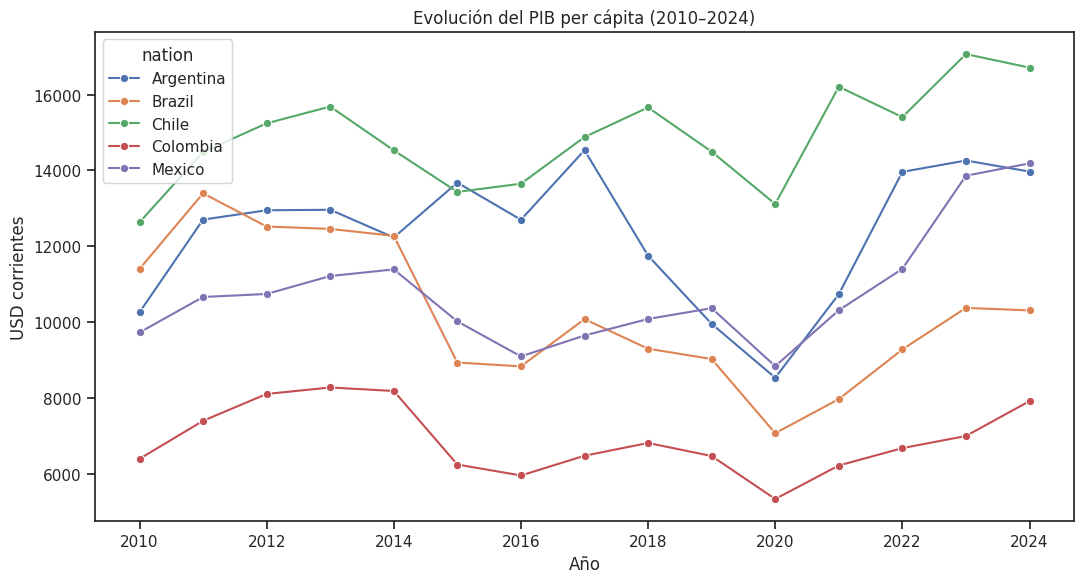

In [15]:
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=datasets["gdp_pc"],
    x="yr",
    y="val",
    hue="nation",
    marker="o"
)
plt.title("Evolución del PIB per cápita (2010–2024)")
plt.xlabel("Año")
plt.ylabel("USD corrientes")
plt.tight_layout()
plt.show()



In [17]:
ref_year = 2022

# Validar existencia de indicadores
if "gdp_pc" not in datasets:
    print("❌ No hay datos de PIB per cápita. No se puede generar el gráfico.")
elif "co2_pc" not in datasets:
    print("❌ No hay datos de CO₂ per cápita. No se puede generar el gráfico.")
else:
    df_g = datasets["gdp_pc"].query("yr == @ref_year").rename(columns={"val": "gdp"})
    df_c = datasets["co2_pc"].query("yr == @ref_year").rename(columns={"val": "co2"})

    merged_df = pd.merge(df_g, df_c, on="nation", how="inner")

    if merged_df.empty:
        print(f"⚠️ No hay datos combinados para el año {ref_year}.")
    else:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=merged_df,
            x="gdp",
            y="co2",
            hue="nation",
            s=130
        )
        plt.title(f"Relación PIB per cápita vs CO₂ per cápita ({ref_year})")
        plt.xlabel("PIB per cápita (USD)")
        plt.ylabel("CO₂ per cápita (toneladas)")
        plt.tight_layout()
        plt.show()



❌ No hay datos de CO₂ per cápita. No se puede generar el gráfico.


In [18]:
engine = create_engine("sqlite:///wb_data.db")
conn = engine.raw_connection()

for alias, df_metric in datasets.items():
    table = f"wb_{alias}"
    df_metric.to_sql(table, con=conn, if_exists="replace", index=False)

preview = pd.read_sql("SELECT * FROM wb_gdp_pc LIMIT 5", conn)
conn.close()

preview



/tmp/ipykernel_1675/3506825864.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_metric.to_sql(table, con=conn, if_exists="replace", index=False)
/tmp/ipykernel_1675/3506825864.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_metric.to_sql(table, con=conn, if_exists="replace", index=False)
/tmp/ipykernel_1675/3506825864.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  preview = pd.read_sql("SELECT * FROM wb_gdp_pc LIMIT 5", conn)


,nation,yr,val
0,Argentina,2010,10260.131311
1,Argentina,2011,12704.283182
2,Argentina,2012,12949.717487
3,Argentina,2013,12963.675773
4,Argentina,2014,12233.144412
